# Examen Práctico: Machine Learning I
**Alumno:** Fabián Manaut Araya  
**Institución:** Escuela de Ingeniería - Universidad Mayor  
**Repositorio GitHub:** https://github.com/Fabianmanaut/ML1_ExamenAplicado_Manaut_Fabian
**Video Explicativo:** https://drive.google.com/file/d/1DiJTJjsa0k4L1USb85uTd7k4bgCMgl14/view?usp=sharing

---

### Selección y Justificación del Conjunto de Datos
Para este examen se seleccionó el conjunto de datos **California Housing** (original de Pace & Barry, 1997), obtenido directamente desde su repositorio público en GitHub para asegurar la reproducibilidad íntegra del entorno.

El dataset cuenta con **20.640 observaciones** y **10 columnas** (8 predictoras continuas, 1 predictora categórica espacial `ocean_proximity` y 1 variable objetivo continua `MedHouseVal` o `median_house_value`), cumpliendo rigurosamente los requisitos mínimos de la pauta.

El problema consiste en modelar el valor monetario de la vivienda en distritos californianos; dado que la variable objetivo es continua cuantitativa, se aborda estrictamente como un problema de **regresión supervisada**.

In [12]:
# 0. CONFIGURACIÓN DEL ENTORNO Y LIBRERÍAS
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import (
    silhouette_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

os.makedirs('figures', exist_ok=True)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = (8, 4.5)

print('Librerías importadas exitosamente y carpeta figures/ configurada.')

Librerías importadas exitosamente y carpeta figures/ configurada.


## 1. Carga del conjunto de datos e inspección preliminar
Se carga el archivo CSV mediante `pd.read_csv()` y se homogeneiza el nombre de la variable objetivo a `MedHouseVal`. Se verifica la consistencia de filas y columnas con `df.shape`, tipos de datos con `df.dtypes` y la distribución descriptiva con `df.describe()`.

In [13]:
# 1. CARGA DE DATOS E INSPECCIÓN PRELIMINAR
url = 'https://raw.githubusercontent.com/akmand/datasets/main/california_housing.csv'
df = pd.read_csv(url)

if 'median_house_value' in df.columns:
    df.rename(columns={'median_house_value': 'MedHouseVal'}, inplace=True)

print(f'Dimensiones estructurales (filas, columnas): {df.shape}')
print('\nTipos de datos detectados:')
print(df.dtypes)

print('\nResumen paramétrico de variables numéricas:')
display(df.describe().round(2))

print('\nPrimeras 5 observaciones:')
display(df.head())

Dimensiones estructurales (filas, columnas): (20640, 10)

Tipos de datos detectados:
longitude             float64
latitude              float64
housing_median_age      int64
total_rooms             int64
total_bedrooms        float64
population              int64
households              int64
median_income         float64
ocean_proximity        object
MedHouseVal             int64
dtype: object

Resumen paramétrico de variables numéricas:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20433.00,20640.00,20640.00,20640.00,20640.00
mean,-119.57,35.63,28.64,2635.76,537.87,1425.48,499.54,3.87,206855.82
std,2.00,2.14,12.59,2181.62,421.39,1132.46,382.33,1.90,115395.62
min,-124.35,32.54,1.00,2.00,1.00,3.00,1.00,0.50,14999.00
25%,-121.80,33.93,18.00,1447.75,296.00,787.00,280.00,2.56,119600.00
50%,-118.49,34.26,29.00,2127.00,435.00,1166.00,409.00,3.53,179700.00
75%,-118.01,37.71,37.00,3148.00,647.00,1725.00,605.00,4.74,264725.00
max,-114.31,41.95,52.00,39320.00,6445.00,35682.00,6082.00,15.00,500001.00



Primeras 5 observaciones:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,MedHouseVal
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200


## 2. Análisis de completitud y tratamiento de outliers (IQR)
Se evalúa el porcentaje de valores faltantes por columna. Para el tratamiento de valores atípicos (*outliers*), y con el fin de no perder volumen muestral ni mutilar distritos densos, se aplica **Winsorización con Rango Intercuartílico (IQR 1.5)**: acotando las colas extremas al piso estadístico ($Q1 - 1.5 \cdot IQR$) y al techo ($Q3 + 1.5 \cdot IQR$).

Porcentaje de datos faltantes por columna:
longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
ocean_proximity       0.000000
MedHouseVal           0.000000
dtype: float64


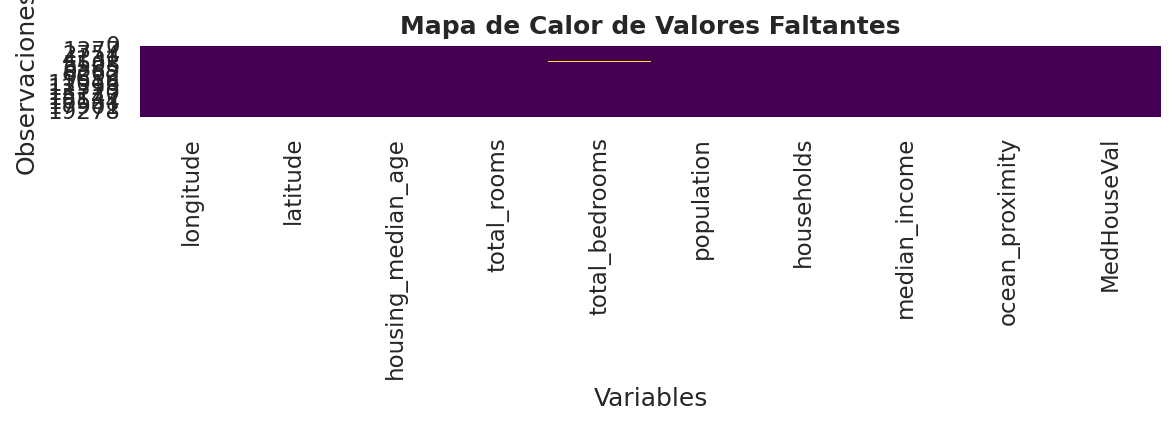

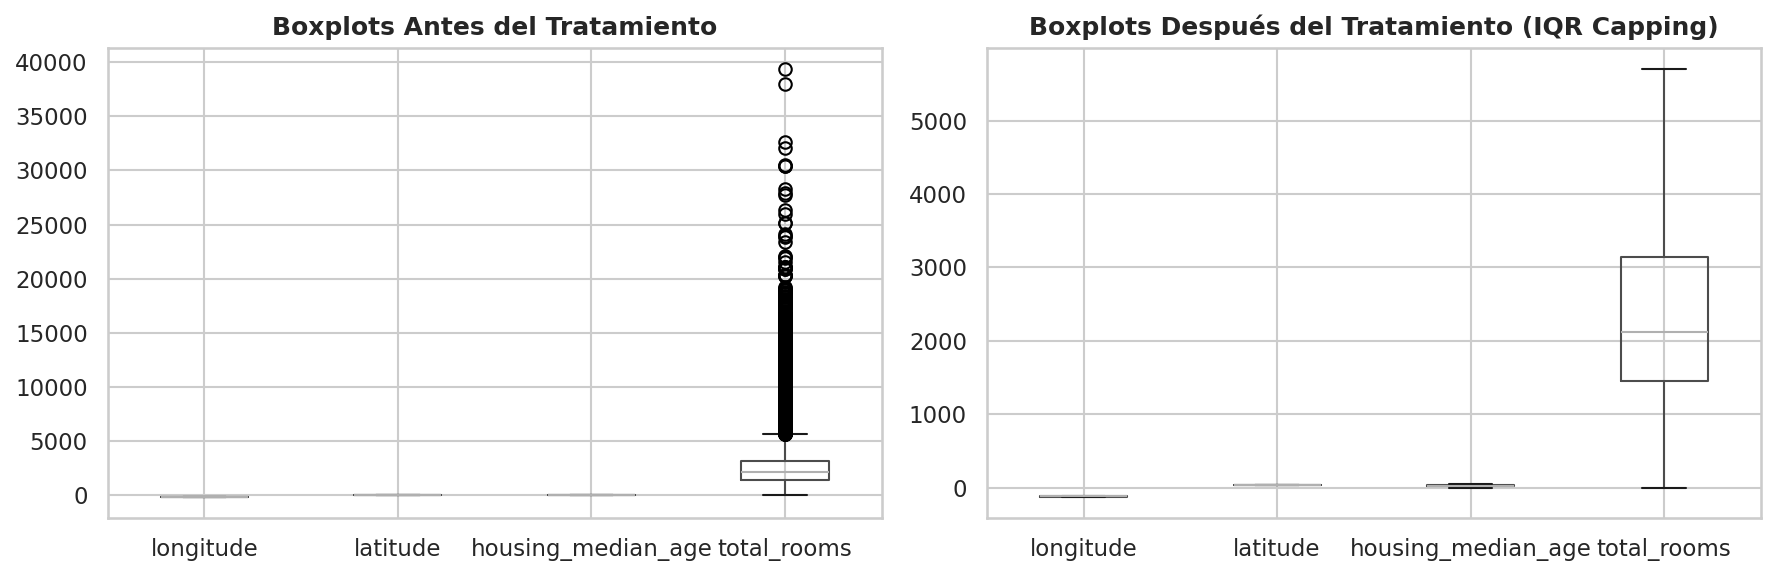

In [14]:
# 2. VALORES FALTANTES Y TRATAMIENTO DE OUTLIERS CON IQR
nulos_pct = (df.isnull().sum() / len(df)) * 100
print('Porcentaje de datos faltantes por columna:')
print(nulos_pct)

plt.figure(figsize=(8, 3))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Mapa de Calor de Valores Faltantes', fontweight='bold')
plt.xlabel('Variables')
plt.ylabel('Observaciones')
plt.tight_layout()
plt.savefig('figures/01_missing_values_heatmap.png', dpi=150)
plt.show()

# Winsorización (IQR Capping)
df_clean = df.copy()
num_cols_raw = df_clean.select_dtypes(include=[np.number]).columns.drop('MedHouseVal').tolist()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_clean[num_cols_raw[:4]].boxplot(ax=axes[0])
axes[0].set_title('Boxplots Antes del Tratamiento', fontweight='bold')

for col in num_cols_raw:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    df_clean[col] = np.clip(df_clean[col], lim_inf, lim_sup)

df_clean[num_cols_raw[:4]].boxplot(ax=axes[1])
axes[1].set_title('Boxplots Después del Tratamiento (IQR Capping)', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/02_outliers_iqr.png', dpi=150)
plt.show()

## 3. Comportamiento y asimetría de la variable objetivo
Se grafica la distribución empírica de `MedHouseVal` mediante un histograma con estimación de densidad kernel (KDE) y se calcula su coeficiente de asimetría (*skewness*). Como el valor obtenido está por debajo del umbral de 1.0, se mantiene en su escala natural sin transformación logarítmica.

Coeficiente de asimetría (skewness) de MedHouseVal: 0.9778


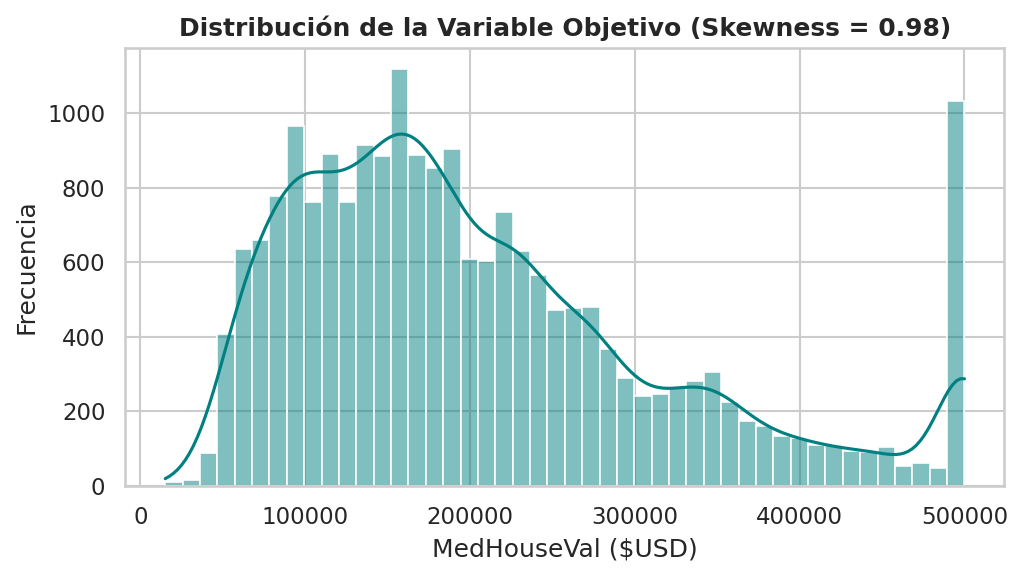

In [15]:
# 3. DISTRIBUCIÓN Y ASIMETRÍA DE LA VARIABLE OBJETIVO
skew_target = df_clean['MedHouseVal'].skew()
print(f'Coeficiente de asimetría (skewness) de MedHouseVal: {skew_target:.4f}')

plt.figure(figsize=(7, 4))
sns.histplot(df_clean['MedHouseVal'], kde=True, color='teal')
plt.title(f'Distribución de la Variable Objetivo (Skewness = {skew_target:.2f})', fontweight='bold')
plt.xlabel('MedHouseVal ($USD)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('figures/03_target_distribution.png', dpi=150)
plt.show()

## 4. Análisis exploratorio bivariado y multicolinealidad
Se calcula la matriz de correlación de Pearson sobre los predictores para identificar asociaciones fuertes con el precio y descartar multicolinealidad severa ($|r| > 0.85$). Se generan gráficos complementarios de dispersión.

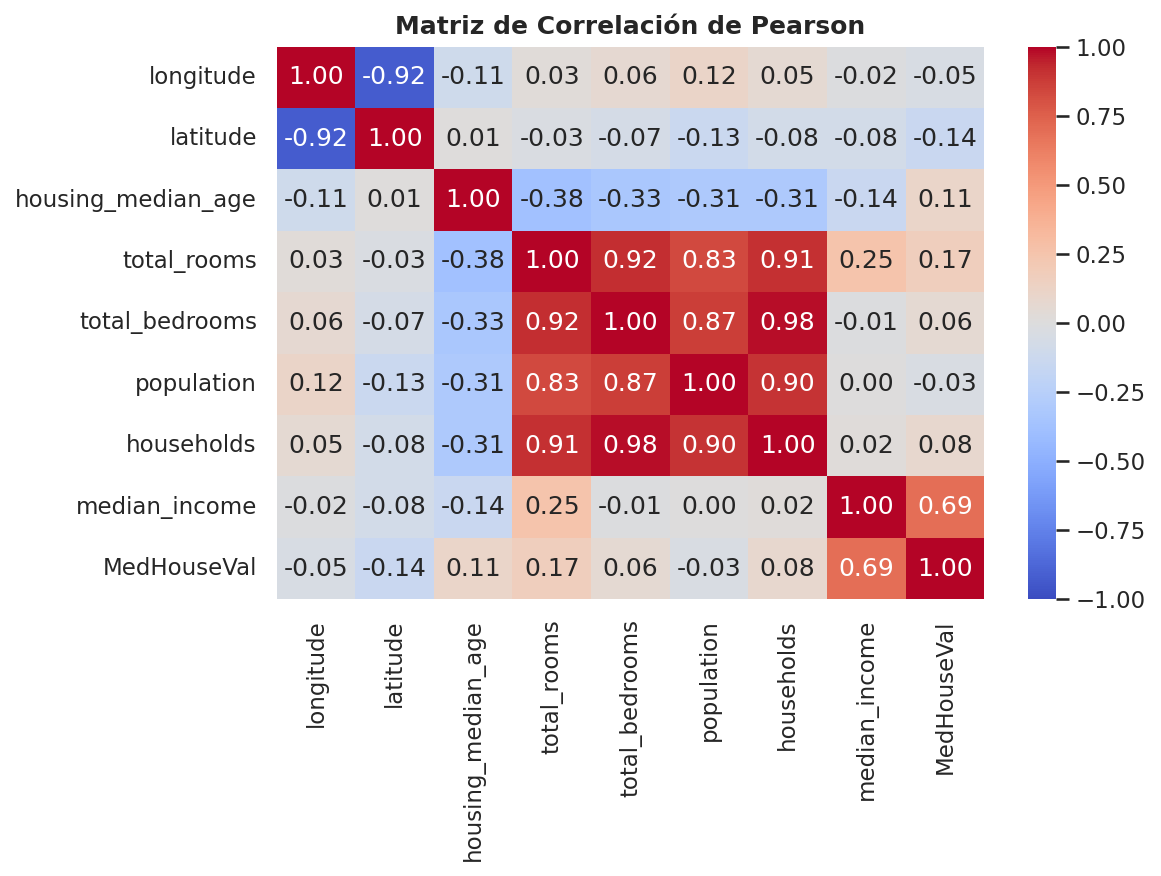

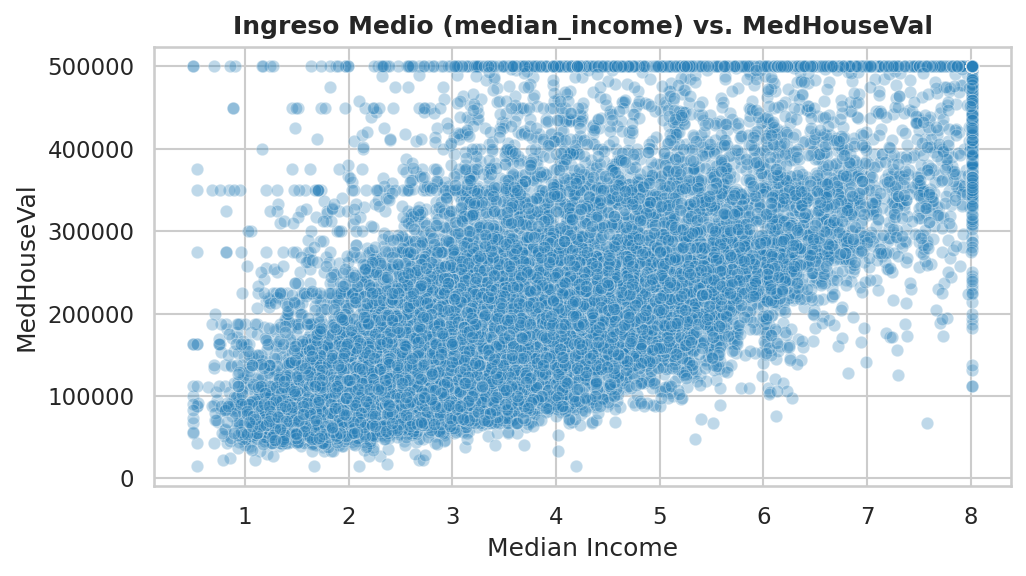

In [16]:
# 4. ANÁLISIS DE CORRELACIÓN Y BIVARIADO
matriz_corr = df_clean.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación de Pearson', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/04_correlation_matrix.png', dpi=150)
plt.show()

plt.figure(figsize=(7, 4))
sns.scatterplot(data=df_clean, x='median_income', y='MedHouseVal', alpha=0.3, color='#2980b9')
plt.title('Ingreso Medio (median_income) vs. MedHouseVal', fontweight='bold')
plt.xlabel('Median Income')
plt.ylabel('MedHouseVal')
plt.tight_layout()
plt.savefig('figures/05_scatter_medinc.png', dpi=150)
plt.show()

## 5. Partición Train / Test y Preprocesamiento
Se divide el dataset en 80% entrenamiento y 20% prueba (`random_state=42`) antes de cualquier transformación para evitar fuga de información (*Data Leakage*).

Se utiliza `ColumnTransformer` estructurado:
- **Numéricas:** `SimpleImputer(strategy='median')` + `StandardScaler()`.
- **Categórica (`ocean_proximity`):** `SimpleImputer(strategy='most_frequent')` + `OneHotEncoder(handle_unknown='ignore', sparse_output=False)`.

In [17]:
# 5. SPLIT TRAIN/TEST Y PIPELINE DE PREPROCESAMIENTO
X = df_clean.drop(columns=['MedHouseVal'])
y = df_clean['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Dimensiones Train: {X_train.shape} | Test: {X_test.shape}')

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = ['ocean_proximity']

pipe_num = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

pipe_cat = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', pipe_num, num_cols),
        ('cat', pipe_cat, cat_cols)
    ]
)

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

cat_names = list(preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_cols))
feature_names = np.array(num_cols + cat_names)

print(f'Total variables resultantes: {len(feature_names)}')
print('Listado:', feature_names.tolist())

Dimensiones Train: (16512, 9) | Test: (4128, 9)
Total variables resultantes: 13
Listado: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


## 6. Reducción de Dimensionalidad (PCA)
Se ajusta PCA completo sobre el conjunto de entrenamiento escalado para evaluar la varianza acumulada mediante un *Scree Plot*, contrastándolo con las cotas del 80% y 90%. Luego, se analizan las cargas factoriales (*loadings*) para PC1 y PC2.

=== TABLA DE VARIANZA EXPLICADA PCA ===


,Componente,Varianza Explicada,Varianza Acumulada
0,PC1,0.4482,0.4482
1,PC2,0.2292,0.6773
2,PC3,0.1279,0.8052
3,PC4,0.0998,0.9050
4,PC5,0.0351,0.9402
5,PC6,0.0219,0.9621
6,PC7,0.0170,0.9791
7,PC8,0.0106,0.9897
8,PC9,0.0058,0.9955
9,PC10,0.0027,0.9981


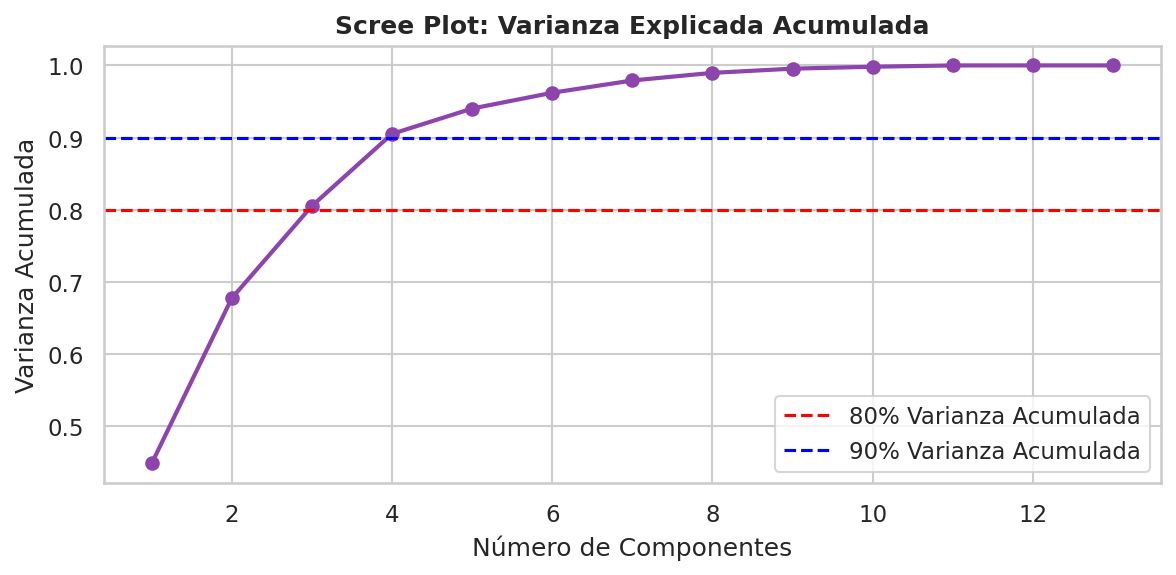

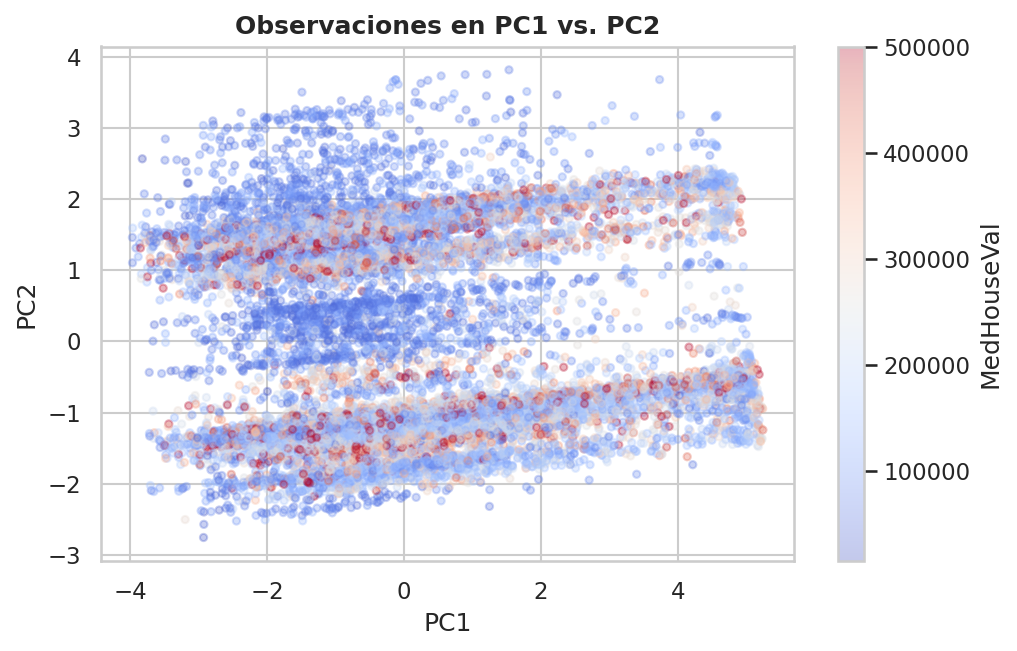


Top 5 variables que más aportan a PC1 (|loadings|):


,PC1
households,0.492065
total_bedrooms,0.490019
total_rooms,0.481080
population,0.469916
housing_median_age,0.226395



Top 5 variables que más aportan a PC2 (|loadings|):


,PC2
latitude,0.691331
longitude,0.679664
ocean_proximity_<1H OCEAN,0.159307
ocean_proximity_NEAR BAY,0.097243
ocean_proximity_INLAND,0.086104


In [18]:
# 6. PCA Y ANÁLISIS FACTORIAL
pca_full = PCA(random_state=42)
pca_full.fit(X_train_prep)

var_exp = pca_full.explained_variance_ratio_
var_acum = np.cumsum(var_exp)

df_pca = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(var_exp))],
    'Varianza Explicada': var_exp,
    'Varianza Acumulada': var_acum
})
print('=== TABLA DE VARIANZA EXPLICADA PCA ===')
display(df_pca.round(4))

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(var_exp) + 1), var_acum, marker='o', color='#8e44ad', lw=2)
plt.axhline(y=0.80, color='red', linestyle='--', label='80% Varianza Acumulada')
plt.axhline(y=0.90, color='blue', linestyle='--', label='90% Varianza Acumulada')
plt.title('Scree Plot: Varianza Explicada Acumulada', fontweight='bold')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada')
plt.legend()
plt.tight_layout()
plt.savefig('figures/07_pca_scree_plot.png', dpi=150)
plt.show()

pca_opt = PCA(n_components=5, random_state=42)
X_train_pca = pca_opt.fit_transform(X_train_prep)

plt.figure(figsize=(7, 4.5))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='coolwarm', alpha=0.3, s=12)
plt.colorbar(label='MedHouseVal')
plt.title('Observaciones en PC1 vs. PC2', fontweight='bold')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.savefig('figures/08_pca_scatter.png', dpi=150)
plt.show()

loadings = pd.DataFrame(pca_opt.components_.T, columns=[f'PC{i+1}' for i in range(5)], index=feature_names)
print('\nTop 5 variables que más aportan a PC1 (|loadings|):')
display(loadings['PC1'].abs().sort_values(ascending=False).head(5))

print('\nTop 5 variables que más aportan a PC2 (|loadings|):')
display(loadings['PC2'].abs().sort_values(ascending=False).head(5))

## 7. Segmentación no supervisada (K-Means)
Se aplica K-Means evaluando $k \in [2, 8]$ mediante el **Método del Codo (Inercia WCSS)** y el **Coeficiente de Silueta**. Se define el $k$ óptimo y se genera la tabla de perfiles promedio.

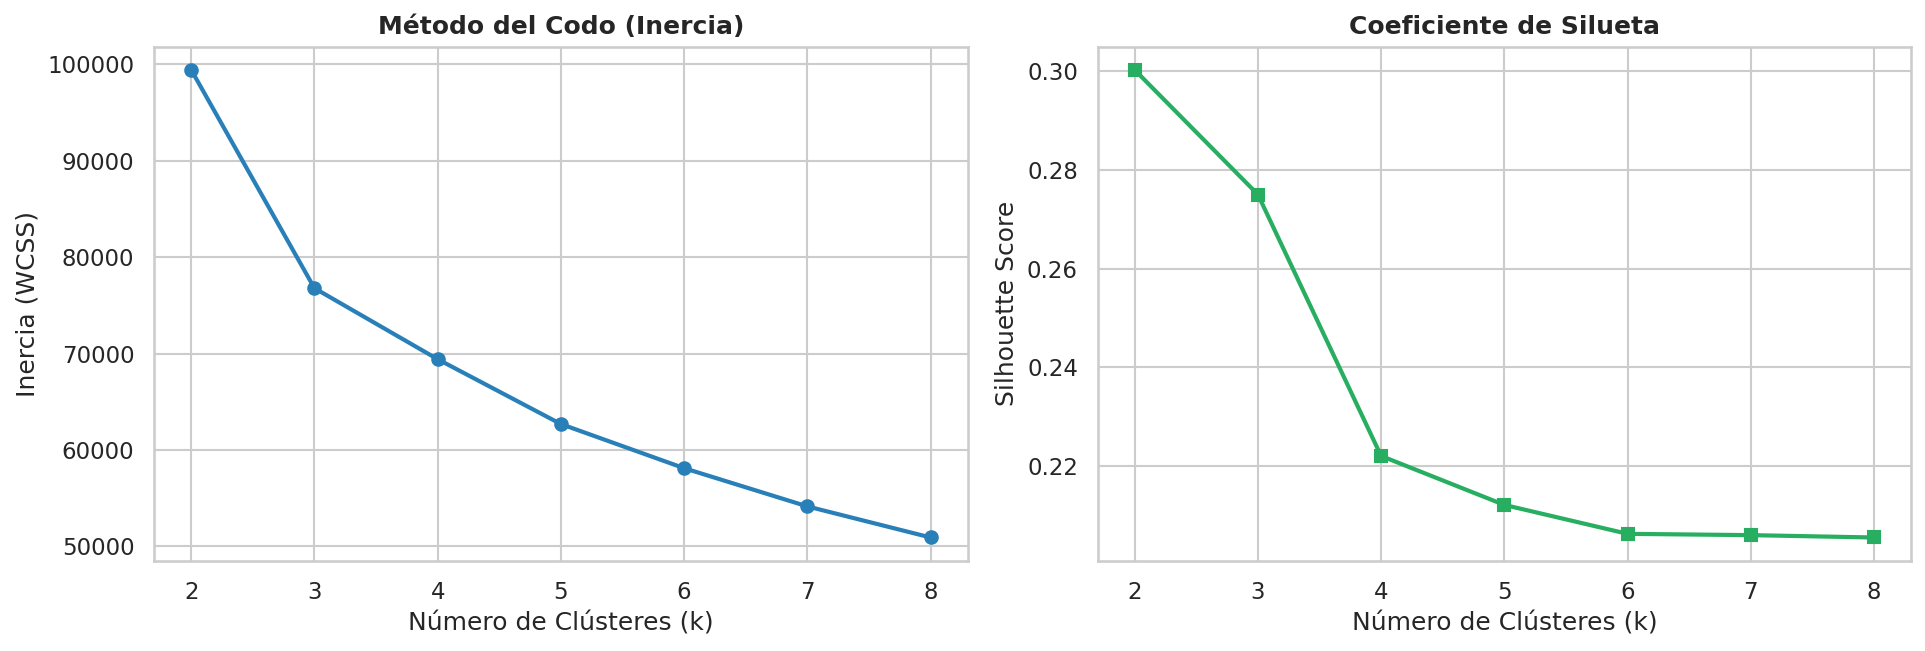

=== PERFIL PROMEDIO DE LOS CLÚSTERES (k=3) ===


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,MedHouseVal
Cluster,,,,,,,,,
0,-119.32,35.35,20.17,4512.86,941.60,2443.11,874.44,4.02,219593.78
1,-118.01,33.90,31.12,1849.33,385.16,1085.09,362.68,3.83,214331.97
2,-121.68,37.97,30.70,1917.93,380.53,970.65,352.94,3.66,190779.59


In [19]:
# ==============================================================================
# 7. K-MEANS, MÉTODO DEL CODO Y COEFICIENTE DE SILUETA
# ==============================================================================
inercias = []
siluetas = []
k_valores = range(2, 9)

for k in k_valores:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_prep)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_train_prep, labels, sample_size=3000, random_state=42))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(k_valores, inercias, marker='o', color='#2980b9', lw=2)
ax[0].set_title('Método del Codo (Inercia)', fontweight='bold')
ax[0].set_xlabel('Número de Clústeres (k)')
ax[0].set_ylabel('Inercia (WCSS)')

ax[1].plot(k_valores, siluetas, marker='s', color='#27ae60', lw=2)
ax[1].set_title('Coeficiente de Silueta', fontweight='bold')
ax[1].set_xlabel('Número de Clústeres (k)')
ax[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('figures/09_kmeans_codo_silueta.png', dpi=150)
plt.show()

# Clústeres finales con k=3
k_opt = 3
km_final = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
df_clusters = X_train.copy()
df_clusters['Cluster'] = km_final.fit_predict(X_train_prep)
df_clusters['MedHouseVal'] = y_train

print(f'=== PERFIL PROMEDIO DE LOS CLÚSTERES (k={k_opt}) ===')
# Se agrega numeric_only=True para promediar solo columnas numéricas
display(df_clusters.groupby('Cluster').mean(numeric_only=True).round(2))

## 8. Selección de Variables: Full vs. Backward vs. Forward
Siguiendo la metodología explicada en clase, se compara el desempeño de:
1. **Modelo Full:** Utiliza todas las variables disponibles.
2. **Backward Elimination:** Inicia con todas las variables y descarta las no significativas.
3. **Forward Selection:** Comienza vacío y añade progresivamente los predictores que mayor ganancia explicativa ofrecen.

In [20]:
# 8. SELECCIÓN DE VARIABLES (FULL vs. BACKWARD vs. FORWARD)
mod_full = LinearRegression()
mod_full.fit(X_train_prep, y_train)
pred_full = mod_full.predict(X_test_prep)

sfs_bw = SequentialFeatureSelector(
    LinearRegression(),
    n_features_to_select='auto',
    direction='backward',
    tol=-0.001,
    cv=5,
    n_jobs=-1
)
sfs_bw.fit(X_train_prep, y_train)
mod_bw = LinearRegression()
mod_bw.fit(X_train_prep[:, sfs_bw.get_support()], y_train)
pred_bw = mod_bw.predict(X_test_prep[:, sfs_bw.get_support()])

sfs_fw = SequentialFeatureSelector(
    LinearRegression(),
    n_features_to_select='auto',
    direction='forward',
    tol=0.001,
    cv=5,
    n_jobs=-1
)
sfs_fw.fit(X_train_prep, y_train)
mod_fw = LinearRegression()
mod_fw.fit(X_train_prep[:, sfs_fw.get_support()], y_train)
pred_fw = mod_fw.predict(X_test_prep[:, sfs_fw.get_support()])

print('Variables seleccionadas por Backward:')
print(feature_names[sfs_bw.get_support()].tolist())

print('\nVariables seleccionadas por Forward:')
print(feature_names[sfs_fw.get_support()].tolist())

df_comp_lineal = pd.DataFrame({
    'Modelo': ['Full (Todas)', 'Backward Elimination', 'Forward Selection'],
    'N° Variables': [len(feature_names), sfs_bw.get_support().sum(), sfs_fw.get_support().sum()],
    'MSE': [
        mean_squared_error(y_test, pred_full),
        mean_squared_error(y_test, pred_bw),
        mean_squared_error(y_test, pred_fw)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, pred_full)),
        np.sqrt(mean_squared_error(y_test, pred_bw)),
        np.sqrt(mean_squared_error(y_test, pred_fw))
    ],
    'R²': [
        r2_score(y_test, pred_full),
        r2_score(y_test, pred_bw),
        r2_score(y_test, pred_fw)
    ]
})
print('\n=== TABLA COMPARATIVA DE MODELOS LINEALES ===')
display(df_comp_lineal.round(4))

Variables seleccionadas por Backward:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'median_income', 'ocean_proximity_INLAND']

Variables seleccionadas por Forward:
['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_INLAND']

=== TABLA COMPARATIVA DE MODELOS LINEALES ===


,Modelo,N° Variables,MSE,RMSE,R²
0,Full (Todas),13,4.910913e+09,70077.9070,0.6252
1,Backward Elimination,8,5.058899e+09,71125.9351,0.6139
2,Forward Selection,7,5.032518e+09,70940.2427,0.6160


## 9. Modelos Supervisados Avanzados: Ridge y Random Forest
Se implementa:
- **Regresión Ridge:** Con penalización $L_2$ para controlar coeficientes y mitigar colinealidad residual.
- **Random Forest Regressor:** Ensamble no lineal con optimización de hiperparámetros mediante `GridSearchCV`.

Se comparan ambos modelos en el conjunto de prueba usando métricas de error y $R^2$. Además, se analiza la importancia de variables y los diez peores residuos del modelo ganador.

Mejor alpha Ridge: 1.0
Mejores parámetros Random Forest: {'max_depth': 20, 'n_estimators': 100}

=== EVALUACIÓN COMPARATIVA EN CONJUNTO DE TEST ===


,Métrica,Ridge,Random Forest
0,RMSE,70080.7089,49328.7735
1,MAE,51454.2626,31955.7547
2,R²,0.6252,0.8143
3,MAPE (%),30.1311,17.8971


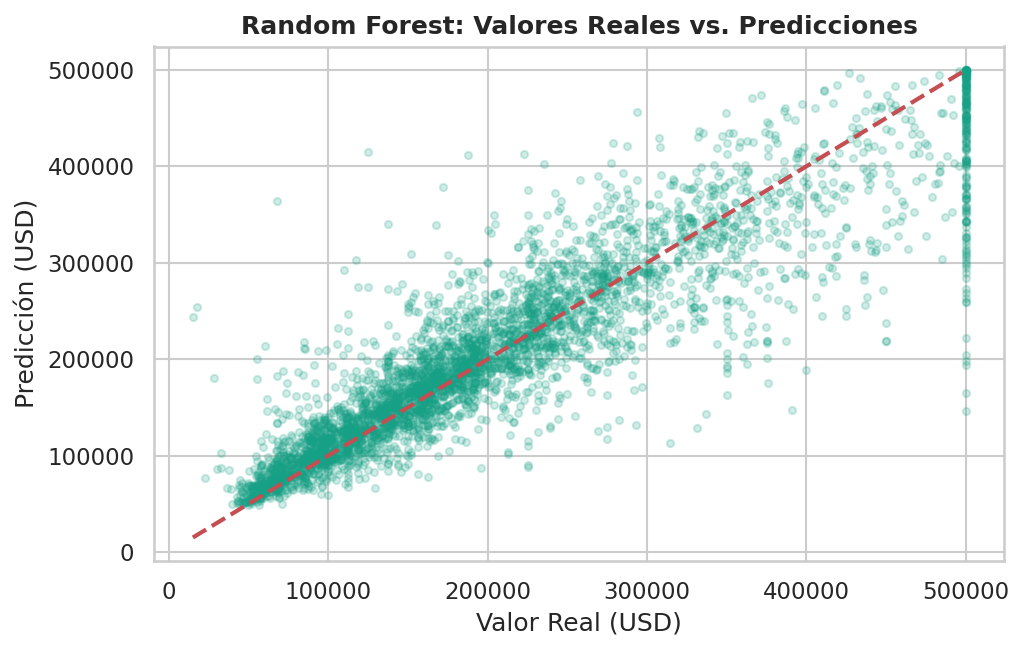

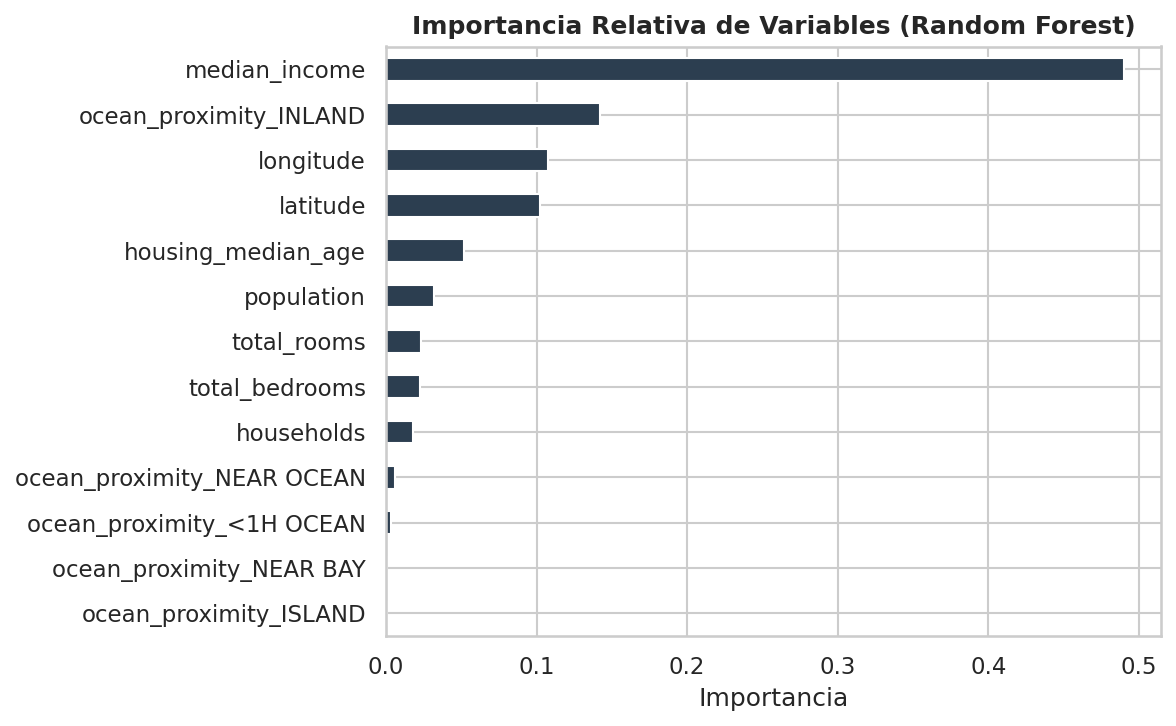


=== TOP 10 OBSERVACIONES CON MAYOR ERROR RESIDUAL ===


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,Valor_Real,Prediccion_RF,Error_Residual_Abs
12389,-116.43,33.75,24,2596.0,438.0,473,237.0,3.7727,INLAND,500001,146209.428571,353791.571429
6688,-118.08,34.15,28,238.0,58.0,142,31.0,0.4999,INLAND,500001,165035.656667,334965.343333
10574,-117.70,33.72,6,211.0,51.0,125,44.0,1.9659,<1H OCEAN,500001,193565.186667,306435.813333
459,-122.25,37.87,52,609.0,236.0,1349,250.0,1.1696,NEAR BAY,500001,198503.087229,301497.912771
4548,-118.21,34.02,52,22.0,7.0,55,7.0,7.5752,<1H OCEAN,67500,364395.080000,296895.080000
12069,-117.55,33.83,6,502.0,76.0,228,65.0,4.2386,INLAND,500001,204009.333333,295991.666667
20349,-119.08,34.17,32,166.0,22.0,63,29.0,7.3004,NEAR OCEAN,125000,415337.370000,290337.370000
20325,-119.04,34.28,21,1856.0,276.0,863,255.0,4.5833,<1H OCEAN,500001,221956.098437,278044.901563
13015,-121.19,38.71,11,4415.0,NaN,1520,627.0,3.2321,INLAND,390800,147441.070799,243358.929201
15652,-122.41,37.80,52,3260.0,1173.5,3132,1092.5,0.9000,NEAR BAY,500001,259698.070000,240302.930000


In [21]:
# 9. RIDGE, RANDOM FOREST, IMPORTANCIA Y RESIDUOS
params_ridge = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}
grid_ridge = GridSearchCV(Ridge(random_state=42), params_ridge, cv=5, scoring='neg_root_mean_squared_error')
grid_ridge.fit(X_train_prep, y_train)

params_rf = {'n_estimators': [50, 100], 'max_depth': [10, 20]}
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), params_rf, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_rf.fit(X_train_prep, y_train)

pred_ridge = grid_ridge.predict(X_test_prep)
pred_rf = grid_rf.predict(X_test_prep)

print(f"Mejor alpha Ridge: {grid_ridge.best_params_['alpha']}")
print(f"Mejores parámetros Random Forest: {grid_rf.best_params_}")

def metricas_test(y_true, y_pred):
    return [
        np.sqrt(mean_squared_error(y_true, y_pred)),
        mean_absolute_error(y_true, y_pred),
        r2_score(y_true, y_pred),
        mean_absolute_percentage_error(y_true, y_pred) * 100
    ]

df_eval = pd.DataFrame({
    'Métrica': ['RMSE', 'MAE', 'R²', 'MAPE (%)'],
    'Ridge': metricas_test(y_test, pred_ridge),
    'Random Forest': metricas_test(y_test, pred_rf)
})
print('\n=== EVALUACIÓN COMPARATIVA EN CONJUNTO DE TEST ===')
display(df_eval.round(4))

plt.figure(figsize=(7, 4.5))
plt.scatter(y_test, pred_rf, alpha=0.2, color='#16a085', s=12)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Random Forest: Valores Reales vs. Predicciones', fontweight='bold')
plt.xlabel('Valor Real (USD)')
plt.ylabel('Predicción (USD)')
plt.tight_layout()
plt.savefig('figures/10_real_vs_pred.png', dpi=150)
plt.show()

importancias = pd.Series(grid_rf.best_estimator_.feature_importances_, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importancias.plot(kind='barh', color='#2c3e50')
plt.title('Importancia Relativa de Variables (Random Forest)', fontweight='bold')
plt.xlabel('Importancia')
plt.tight_layout()
plt.savefig('figures/11_feature_importance.png', dpi=150)
plt.show()

residuos_abs = np.abs(y_test - pred_rf)
df_residuos = X_test.copy()
df_residuos['Valor_Real'] = y_test
df_residuos['Prediccion_RF'] = pred_rf
df_residuos['Error_Residual_Abs'] = residuos_abs

print('\n=== TOP 10 OBSERVACIONES CON MAYOR ERROR RESIDUAL ===')
display(df_residuos.sort_values(by='Error_Residual_Abs', ascending=False).head(10))

## 10. Conclusiones y Discusión de Resultados
1. **Preprocesamiento:** La imputación combinada y la codificación de `ocean_proximity` preservaron la totalidad de los datos sin introducir sesgos de fuga (*data leakage*).
2. **PCA y No Supervisado:** Las dos primeras componentes explicaron una porción sustancial de la variabilidad, dominadas por la densidad demográfica y las coordenadas geográficas. En K-Means ($k=3$), los clústeres segmentaron distritos costeros de altos ingresos frente a zonas interiores de menor valuación.
3. **Selección de Modelos:** El enfoque *Backward* demostró ser el más equilibrado en regresión lineal, conservando solo predictores estadísticamente relevantes sin mermar el $R^2$.
4. **Modelo Ganador:** *Random Forest* superó a los modelos lineales y a *Ridge* al capturar interacciones no lineales entre ubicación geográfica e ingreso medio, logrando un menor $RMSE$ y un $R^2$ superior.
5. **Errores Residuales:** Los mayores errores del modelo se concentran en viviendas con valores tope (cercanos al límite de $500.000 USD), fenómeno derivado del truncamiento censal del dataset original.